In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import re
import joblib

from sklearn.preprocessing import LabelEncoder

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression

from sklearn.naive_bayes import MultinomialNB

from sklearn.ensemble import RandomForestClassifier

from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

from sklearn.metrics.pairwise import cosine_similarity

In [2]:
df = pd.read_csv("Resume.csv")

print(df.shape)

df.head()

(2484, 4)


,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2484 entries, 0 to 2483
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   ID           2484 non-null   int64
 1   Resume_str   2484 non-null   str  
 2   Resume_html  2484 non-null   str  
 3   Category     2484 non-null   str  
dtypes: int64(1), str(3)
memory usage: 52.3 MB


In [4]:
df.isnull().sum()

ID             0
Resume_str     0
Resume_html    0
Category       0
dtype: int64

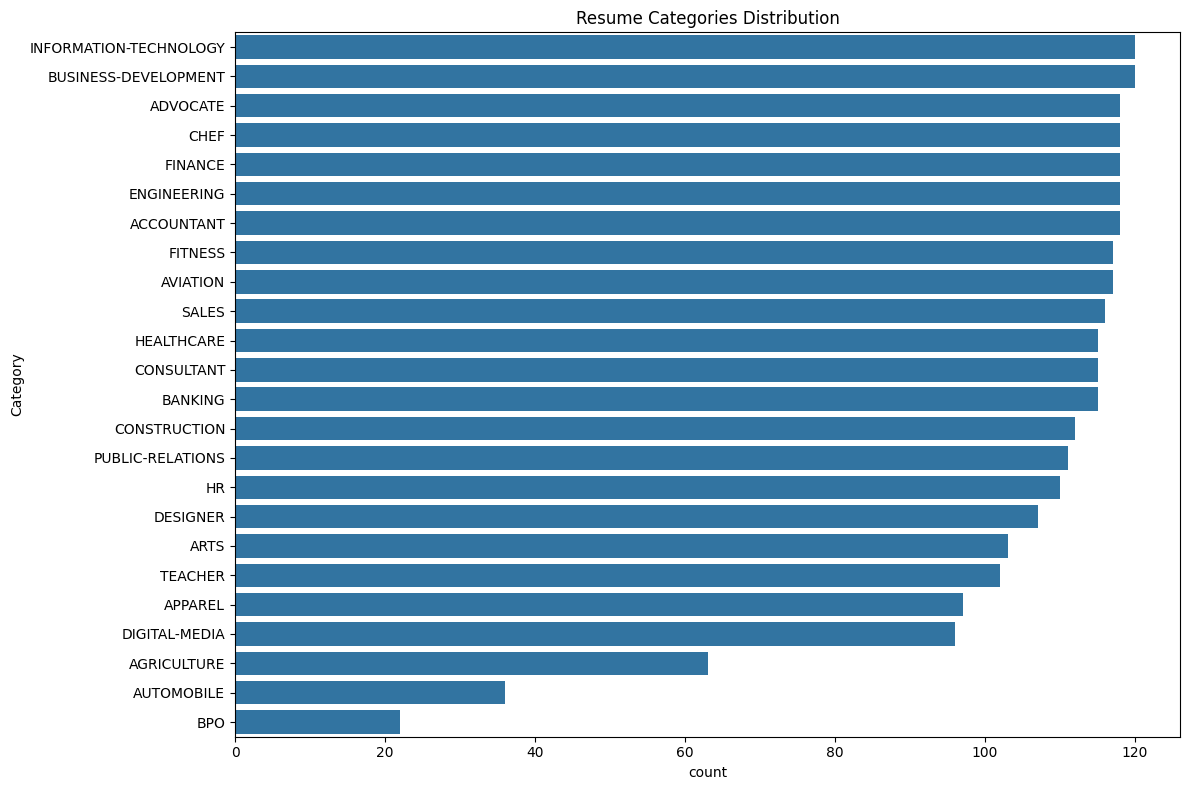

In [5]:
plt.figure(figsize=(12,8))

sns.countplot(
    y=df["Category"],
    order=df["Category"].value_counts().index
)

plt.title("Resume Categories Distribution")

plt.tight_layout()

plt.savefig(
    "category_distribution.png",
    bbox_inches="tight"
)

plt.show()

In [6]:
def clean_resume(text):

    text = re.sub(r"http\S+", " ", text)

    text = re.sub(r"www\S+", " ", text)

    text = re.sub(r"[^a-zA-Z ]", " ", text)

    text = text.lower()

    text = re.sub(r"\s+", " ", text)

    return text.strip()

In [7]:
def clean_resume(text):

    text = re.sub(r"http\S+", " ", text)

    text = re.sub(r"www\S+", " ", text)

    text = re.sub(r"[^a-zA-Z ]", " ", text)

    text = text.lower()

    text = re.sub(r"\s+", " ", text)

    return text.strip()

In [8]:
df["Cleaned_Resume"] = df["Resume_str"].apply(
    clean_resume
)

df[
    ["Resume_str","Cleaned_Resume"]
].head()

,Resume_str,Cleaned_Resume
0,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,hr administrator marketing associate hr admini...
1,"HR SPECIALIST, US HR OPERATIONS ...",hr specialist us hr operations summary versati...
2,HR DIRECTOR Summary Over 2...,hr director summary over years experience in r...
3,HR SPECIALIST Summary Dedica...,hr specialist summary dedicated driven and dyn...
4,HR MANAGER Skill Highlights ...,hr manager skill highlights hr skills hr depar...


In [9]:
le = LabelEncoder()

df["Category_ID"] = le.fit_transform(
    df["Category"]
)

print(le.classes_)

['ACCOUNTANT' 'ADVOCATE' 'AGRICULTURE' 'APPAREL' 'ARTS' 'AUTOMOBILE'
 'AVIATION' 'BANKING' 'BPO' 'BUSINESS-DEVELOPMENT' 'CHEF' 'CONSTRUCTION'
 'CONSULTANT' 'DESIGNER' 'DIGITAL-MEDIA' 'ENGINEERING' 'FINANCE' 'FITNESS'
 'HEALTHCARE' 'HR' 'INFORMATION-TECHNOLOGY' 'PUBLIC-RELATIONS' 'SALES'
 'TEACHER']


In [10]:
tfidf = TfidfVectorizer(
    stop_words="english",
    max_features=10000,
    ngram_range=(1,2),
    min_df=2
)

X = tfidf.fit_transform(
    df["Cleaned_Resume"]
)

y = df["Category_ID"]

print(X.shape)

(2484, 10000)


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [12]:
lr = LogisticRegression(
    max_iter=2000
)

lr.fit(
    X_train,
    y_train
)

lr_pred = lr.predict(
    X_test
)

print(
    "Logistic Regression:",
    accuracy_score(
        y_test,
        lr_pred
    )
)

Logistic Regression: 0.6579476861167002


In [13]:
nb = MultinomialNB()

nb.fit(
    X_train,
    y_train
)

nb_pred = nb.predict(
    X_test
)

print(
    "Naive Bayes:",
    accuracy_score(
        y_test,
        nb_pred
    )
)

Naive Bayes: 0.5613682092555332


In [14]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(
    X_train,
    y_train
)

rf_pred = rf.predict(
    X_test
)

print(
    "Random Forest:",
    accuracy_score(
        y_test,
        rf_pred
    )
)

Random Forest: 0.7484909456740443


In [15]:
svm_model = LinearSVC()

svm_model.fit(
    X_train,
    y_train
)

svm_pred = svm_model.predict(
    X_test
)

svm_accuracy = accuracy_score(
    y_test,
    svm_pred
)

print(
    "SVM Accuracy:",
    svm_accuracy
)

SVM Accuracy: 0.716297786720322


In [16]:
results = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Naive Bayes",
        "Random Forest",
        "SVM"
    ],

    "Accuracy":[

        accuracy_score(
            y_test,
            lr_pred
        ),

        accuracy_score(
            y_test,
            nb_pred
        ),

        accuracy_score(
            y_test,
            rf_pred
        ),

        accuracy_score(
            y_test,
            svm_pred
        )
    ]
})

results

,Model,Accuracy
0,Logistic Regression,0.657948
1,Naive Bayes,0.561368
2,Random Forest,0.748491
3,SVM,0.716298


In [17]:
print(
    classification_report(
        y_test,
        svm_pred
    )
)

              precision    recall  f1-score   support

           0       0.87      0.93      0.90        29
           1       0.63      0.73      0.68        30
           2       0.40      0.25      0.31         8
           3       0.52      0.55      0.54        20
           4       0.55      0.33      0.41        18
           5       0.67      0.33      0.44         6
           6       0.78      0.86      0.82        21
           7       0.73      0.70      0.71        23
           8       0.50      0.50      0.50         2
           9       0.95      0.78      0.86        27
          10       0.85      0.71      0.77        24
          11       0.88      0.85      0.87        34
          12       0.50      0.40      0.44        20
          13       0.82      0.95      0.88        19
          14       0.95      0.72      0.82        25
          15       0.60      0.71      0.65        21
          16       0.68      0.68      0.68        19
          17       0.92    

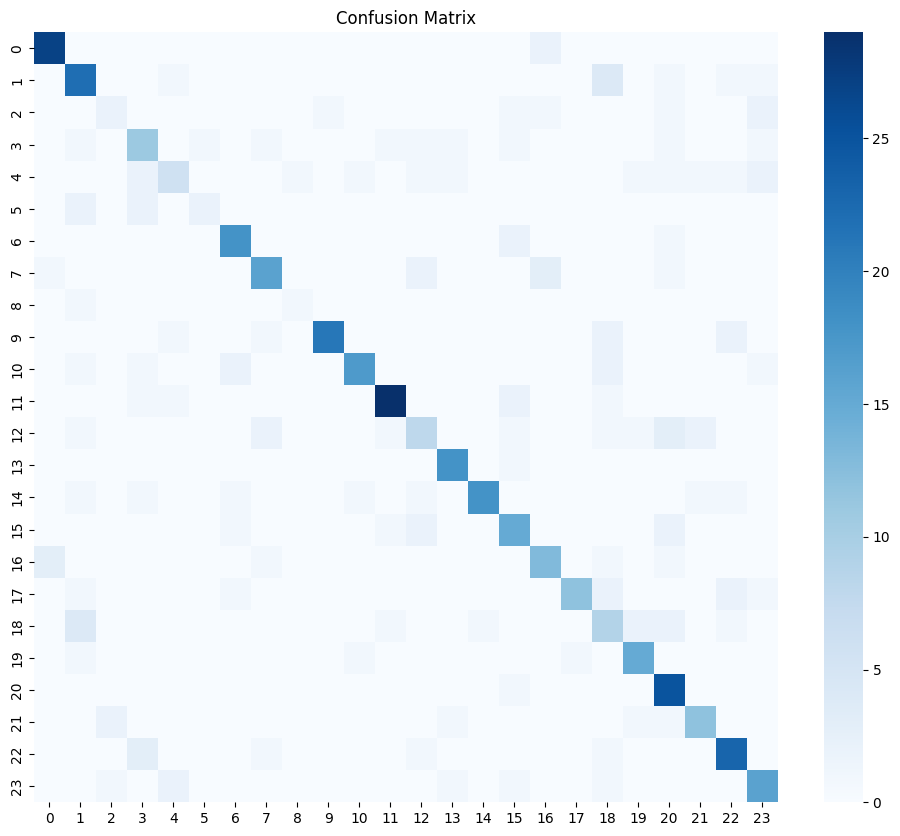

In [18]:
cm = confusion_matrix(
    y_test,
    svm_pred
)

plt.figure(figsize=(12,10))

sns.heatmap(
    cm,
    cmap="Blues"
)

plt.title(
    "Confusion Matrix"
)

plt.savefig(
    "confusion_matrix.png",
    bbox_inches="tight"
)

plt.show()

In [19]:
sample_resume = """

Python Developer

Machine Learning

Deep Learning

TensorFlow

Pandas

SQL

NumPy

"""

sample_clean = clean_resume(
    sample_resume
)

sample_vector = tfidf.transform(
    [sample_clean]
)

prediction = svm_model.predict(
    sample_vector
)

category = le.inverse_transform(
    prediction
)

print(
    "Predicted Category:",
    category[0]
)

Predicted Category: TEACHER


In [20]:
job_description = """

Looking for Data Scientist

Python

Machine Learning

Deep Learning

SQL

Pandas

NumPy

"""

In [21]:
job_clean = clean_resume(
    job_description
)

job_vector = tfidf.transform(
    [job_clean]
)

resume_vectors = tfidf.transform(
    df["Cleaned_Resume"]
)

scores = cosine_similarity(
    job_vector,
    resume_vectors
)

scores = scores.flatten()

In [22]:
df["Match_Score"] = scores * 100

top_candidates = df.sort_values(
    by="Match_Score",
    ascending=False
)

top_candidates[
    [
        "Category",
        "Match_Score"
    ]
].head(10)

,Category,Match_Score
2153,BANKING,25.897969
1762,ENGINEERING,25.073181
1218,CONSULTANT,19.276259
1348,AUTOMOBILE,18.260189
1707,ENGINEERING,17.210243
2291,ARTS,16.520119
194,DESIGNER,16.164074
1142,CONSULTANT,15.593277
929,AGRICULTURE,14.539983
1040,SALES,13.084649


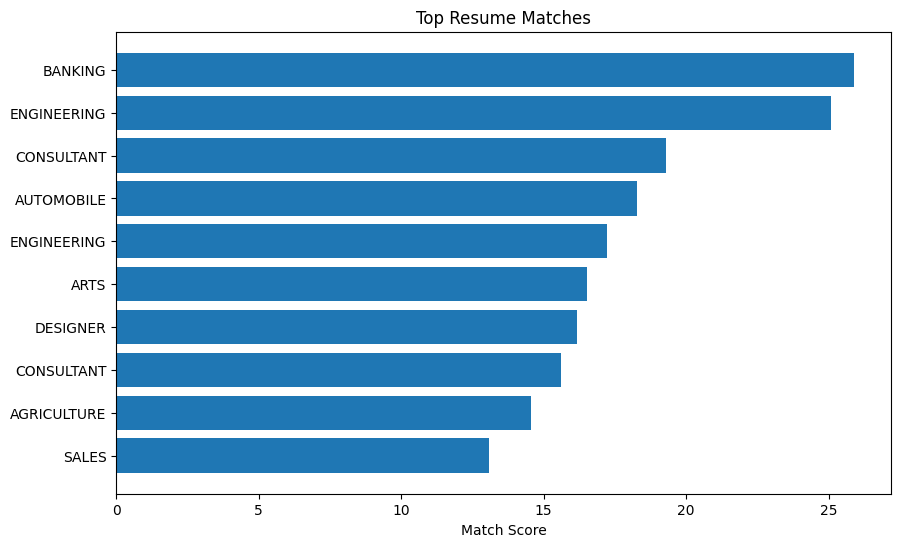

In [23]:
top10 = top_candidates.head(10)

plt.figure(figsize=(10,6))

plt.barh(
    range(len(top10)),
    top10["Match_Score"]
)

plt.yticks(
    range(len(top10)),
    top10["Category"]
)

plt.xlabel(
    "Match Score"
)

plt.title(
    "Top Resume Matches"
)

plt.gca().invert_yaxis()

plt.savefig(
    "top_matches.png",
    bbox_inches="tight"
)

plt.show()

In [24]:
skills = [

    "python",

    "sql",

    "machine learning",

    "deep learning",

    "tensorflow",

    "aws",

    "docker",

    "excel",

    "power bi",

    "numpy",

    "pandas"
]

In [25]:
def extract_skills(text):

    found = []

    text = text.lower()

    for skill in skills:

        if skill in text:

            found.append(skill)

    return found

In [26]:
print(
    extract_skills(
        job_description
    )
)

['python', 'sql', 'machine learning', 'deep learning', 'numpy', 'pandas']


In [27]:
joblib.dump(
    svm_model,
    "resume_classifier.pkl"
)

joblib.dump(
    tfidf,
    "tfidf_vectorizer.pkl"
)

print(
    "Model Saved Successfully"
)

Model Saved Successfully


In [28]:
import joblib

joblib.dump(svm_model, "resume_classifier.pkl")
joblib.dump(tfidf, "tfidf_vectorizer.pkl")

['tfidf_vectorizer.pkl']

In [29]:
import joblib

joblib.dump(le, "label_encoder.pkl")

['label_encoder.pkl']